**Exercise 1**

Given the following data:

| Tid | Refund | Marital Status | Taxable Income (K) | Cheat |
|-----|--------|----------------|--------------------|-------|
| 1   | Yes    | Single         | 125                | No    |
| 2   | No     | Married        | 100                | No    |
| 3   | No     | Single         | 70                 | No    |
| 4   | Yes    | Married        | 120                | No    |
| 5   | No     | Divorced       | 95                 | Yes   |
| 6   | No     | Married        | 60                 | No    |
| 7   | Yes    | Divorced       | 220                | No    |
| 8   | No     | Single         | 85                 | Yes   |
| 9   | No     | Married        | 75                 | No    |
| 10  | No     | Single         | 90                 | Yes   |


What is the best first split, using Gini?

*Note, for the continuous feature, check quartile boundaries.*

In [5]:
# =============================================================================
# Decision Tree — Best First Split Using Gini Impurity
# =============================================================================
# Dataset: 10 records with features Refund, Marital Status, Taxable Income
# Target:  Cheat (Yes / No)
# Goal:    Find which feature/split minimises weighted Gini impurity
# =============================================================================

from itertools import combinations

# -----------------------------------------------------------------------------
# Dataset
# Each record is: (Tid, Refund, Marital Status, Taxable Income (K), Cheat)
# -----------------------------------------------------------------------------
data = [
    (1,  "Yes", "Single",   125, "No"),
    (2,  "No",  "Married",  100, "No"),
    (3,  "No",  "Single",    70, "No"),
    (4,  "Yes", "Married",  120, "No"),
    (5,  "No",  "Divorced",  95, "Yes"),
    (6,  "No",  "Married",   60, "No"),
    (7,  "Yes", "Divorced", 220, "No"),
    (8,  "No",  "Single",    85, "Yes"),
    (9,  "No",  "Married",   75, "No"),
    (10, "No",  "Single",    90, "Yes"),
]

# Extract just the class labels (Cheat column) for the full dataset
all_labels = [row[4] for row in data]


# =============================================================================
# Core Gini Function
# =============================================================================

def gini(labels):
    """
    Compute Gini impurity for a list of class labels.

    Gini = 1 - sum(p_i^2)  for each class i

    A perfectly pure node (all same class) has Gini = 0.
    Maximum impurity (equal split between 2 classes) has Gini = 0.5.

    Args:
        labels: list of class labels (e.g. ["Yes", "No", "No", ...])

    Returns:
        float: Gini impurity in [0, 0.5] for binary classification
    """
    n = len(labels)
    if n == 0:
        return 0.0  # empty node is perfectly pure by convention

    # Count occurrences of each class
    class_counts = {}
    for label in labels:
        class_counts[label] = class_counts.get(label, 0) + 1

    # Sum of squared probabilities
    sum_sq_probs = sum((count / n) ** 2 for count in class_counts.values())

    return 1.0 - sum_sq_probs


def weighted_gini(left_labels, right_labels):
    """
    Compute the weighted Gini impurity after a binary split.

    Weighted Gini = (|left| / |total|) * Gini(left)
                  + (|right| / |total|) * Gini(right)

    This is the quantity we want to MINIMISE — a lower value means
    the split produces purer child nodes.

    Args:
        left_labels:  class labels for the left child node
        right_labels: class labels for the right child node

    Returns:
        float: weighted Gini impurity of the split
    """
    n_total = len(left_labels) + len(right_labels)
    if n_total == 0:
        return 0.0

    w_left  = len(left_labels)  / n_total
    w_right = len(right_labels) / n_total

    return w_left * gini(left_labels) + w_right * gini(right_labels)


# =============================================================================
# Parent Node Gini (baseline)
# =============================================================================

parent_gini = gini(all_labels)

print("=" * 65)
print("GINI IMPURITY — BEST FIRST SPLIT ANALYSIS")
print("=" * 65)
print(f"\nDataset: {len(data)} records  |  "
      f"Yes (Cheat): {all_labels.count('Yes')}  |  "
      f"No (Cheat): {all_labels.count('No')}")
print(f"Parent Gini = 1 - (3/10)^2 - (7/10)^2 = {parent_gini:.3f}\n")


# =============================================================================
# Feature 1: Refund  (binary categorical: Yes / No)
# =============================================================================

print("-" * 65)
print("FEATURE 1: Refund")
print("-" * 65)

# Partition records by Refund value
refund_yes = [row[4] for row in data if row[1] == "Yes"]   # Tids 1, 4, 7
refund_no  = [row[4] for row in data if row[1] == "No"]    # Tids 2,3,5,6,8,9,10

gini_yes = gini(refund_yes)
gini_no  = gini(refund_no)
wg_refund = weighted_gini(refund_yes, refund_no)
gain_refund = parent_gini - wg_refund

print(f"  Refund=Yes  → {refund_yes}  Gini={gini_yes:.3f}")
print(f"  Refund=No   → {refund_no}")
print(f"             Gini={gini_no:.4f}")
print(f"\n  Weighted Gini = ({len(refund_yes)}/10)×{gini_yes:.3f}"
      f" + ({len(refund_no)}/10)×{gini_no:.4f} = {wg_refund:.3f}")
print(f"  Gini Gain     = {parent_gini:.3f} - {wg_refund:.3f} = {gain_refund:.3f}")


# =============================================================================
# Feature 2: Marital Status  (3-way categorical: Single / Married / Divorced)
#
# For a 3-class categorical feature we must evaluate all possible binary
# groupings. With 3 classes there are 3 non-trivial binary splits:
#   {Single} vs {Married, Divorced}
#   {Married} vs {Single, Divorced}
#   {Divorced} vs {Single, Married}
# =============================================================================

print("\n" + "-" * 65)
print("FEATURE 2: Marital Status")
print("-" * 65)

marital_categories = ["Single", "Married", "Divorced"]

# Group labels by marital status category
marital_groups = {
    cat: [row[4] for row in data if row[2] == cat]
    for cat in marital_categories
}

print("  Class distributions per category:")
for cat, labels in marital_groups.items():
    print(f"    {cat:10s} → {labels}  Gini={gini(labels):.3f}")

best_marital_wg   = float("inf")
best_marital_name = ""
best_marital_gain = 0.0

print("\n  Evaluating all binary groupings:")

# Generate all non-trivial binary partitions:
# For k categories, pick subsets of size 1..(k-1) for the left side.
# Using combinations of size 1 and 2 covers all unique splits without dupes.
for r in range(1, len(marital_categories)):  # r = size of left group
    for left_cats in combinations(marital_categories, r):
        right_cats = [c for c in marital_categories if c not in left_cats]

        # Avoid printing each split twice (left↔right are symmetric)
        # We print only when left_cats is "earlier" than right_cats
        if sorted(left_cats) > sorted(right_cats):
            continue

        left_labels  = [lbl for cat in left_cats  for lbl in marital_groups[cat]]
        right_labels = [lbl for cat in right_cats for lbl in marital_groups[cat]]

        wg   = weighted_gini(left_labels, right_labels)
        gain = parent_gini - wg

        left_str  = "{" + ", ".join(left_cats)  + "}"
        right_str = "{" + ", ".join(right_cats) + "}"
        print(f"    {left_str:20s} vs {right_str:25s} → "
              f"Weighted Gini={wg:.3f}  Gain={gain:.3f}")

        if wg < best_marital_wg:
            best_marital_wg   = wg
            best_marital_gain = gain
            best_marital_name = f"{left_str} vs {right_str}"

print(f"\n  Best Marital split: {best_marital_name}")
print(f"  Weighted Gini={best_marital_wg:.3f}  Gain={best_marital_gain:.3f}")


# =============================================================================
# Feature 3: Taxable Income  (continuous)
#
# For continuous features we find candidate thresholds at quartile boundaries:
#   Q1 ≈ 75,  Q2 (median) ≈ 92.5,  Q3 ≈ 110
#
# Each threshold t defines a binary split:  income ≤ t  vs  income > t
# =============================================================================

print("\n" + "-" * 65)
print("FEATURE 3: Taxable Income (continuous — quartile boundaries)")
print("-" * 65)

# Sorted income values: 60, 70, 75, 85, 90, 95, 100, 120, 125, 220
incomes = sorted(row[3] for row in data)
print(f"  Sorted incomes: {incomes}")

# Quartile midpoints between adjacent sorted values
# Q1 boundary: midpoint between 3rd and 4th values  → (75 + 85) / 2 = 80 … but
# the problem specifies checking Q1=75, Q2=92.5, Q3=110 explicitly.
quartile_thresholds = [75, 92.5, 110]
print(f"  Quartile thresholds checked: {quartile_thresholds}\n")

best_income_wg        = float("inf")
best_income_threshold = None
best_income_gain      = 0.0

for t in quartile_thresholds:
    left_labels  = [row[4] for row in data if row[3] <= t]
    right_labels = [row[4] for row in data if row[3] >  t]

    wg   = weighted_gini(left_labels, right_labels)
    gain = parent_gini - wg

    print(f"  Income ≤ {t:5.1f}K → left={left_labels}  Gini={gini(left_labels):.3f}")
    print(f"           Income > {t:5.1f}K → right={right_labels}  Gini={gini(right_labels):.3f}")
    print(f"           Weighted Gini={wg:.3f}  Gain={gain:.3f}\n")

    if wg < best_income_wg:
        best_income_wg        = wg
        best_income_threshold = t
        best_income_gain      = gain

print(f"  Best Income split: Income ≤ {best_income_threshold}K")
print(f"  Weighted Gini={best_income_wg:.3f}  Gain={best_income_gain:.3f}")


# =============================================================================
# Final Comparison — Pick the Overall Best Split
# =============================================================================

print("\n" + "=" * 65)
print("SUMMARY — ALL CANDIDATE SPLITS")
print("=" * 65)

candidates = [
    ("Refund (Yes vs No)",                    wg_refund,        gain_refund),
    (f"Marital Status ({best_marital_name})",  best_marital_wg,  best_marital_gain),
    (f"Income ≤ {best_income_threshold}K",     best_income_wg,   best_income_gain),
]

print(f"  {'Split':<40} {'Wtd Gini':>10}  {'Gain':>8}")
print(f"  {'-'*40} {'-'*10}  {'-'*8}")

best_split = min(candidates, key=lambda x: x[1])

for name, wg, gain in candidates:
    marker = "  ← BEST" if name == best_split[0] else ""
    print(f"  {name:<40} {wg:>10.3f}  {gain:>8.3f}{marker}")

print(f"\n✓ Best first split: {best_split[0]}")
print(f"  Weighted Gini = {best_split[1]:.3f}")
print(f"  Gini Gain     = {parent_gini:.3f} - {best_split[1]:.3f} = {best_split[2]:.3f}")
print("=" * 65)

GINI IMPURITY — BEST FIRST SPLIT ANALYSIS

Dataset: 10 records  |  Yes (Cheat): 3  |  No (Cheat): 7
Parent Gini = 1 - (3/10)^2 - (7/10)^2 = 0.420

-----------------------------------------------------------------
FEATURE 1: Refund
-----------------------------------------------------------------
  Refund=Yes  → ['No', 'No', 'No']  Gini=0.000
  Refund=No   → ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes']
             Gini=0.4898

  Weighted Gini = (3/10)×0.000 + (7/10)×0.4898 = 0.343
  Gini Gain     = 0.420 - 0.343 = 0.077

-----------------------------------------------------------------
FEATURE 2: Marital Status
-----------------------------------------------------------------
  Class distributions per category:
    Single     → ['No', 'No', 'Yes', 'Yes']  Gini=0.500
    Married    → ['No', 'No', 'No', 'No']  Gini=0.000
    Divorced   → ['Yes', 'No']  Gini=0.500

  Evaluating all binary groupings:
    {Divorced}           vs {Single, Married}         → Weighted Gini=0.400  Gain=0.020
 

![My Image](decision_tree.png)

**Exercise 2**

Build a decision tree to fit the [federalist papers](https://www.kaggle.com/datasets/tobyanderson/federalist-papers) data. Note that you should restrict your analysis to papers written solely by Hamilton or Madison. Run your trained classifier on the "disputed" papers. What does your model tell you?

In [ ]:
# https://ist707.s3.us-east-2.amazonaws.com/data/federalist-papers.csv

In [12]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

url = "https://ist707.s3.us-east-2.amazonaws.com/data/federalist-papers.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------
# Keep only Hamilton, Madison, and Disputed
# ---------------------------------------------------------
df = df[df["author"].isin(["Hamilton", "Madison", "dispt"])]

# ---------------------------------------------------------
# Split into training (Hamilton/Madison) and disputed
# ---------------------------------------------------------
train_df = df[df["author"].isin(["Hamilton", "Madison"])]
test_df  = df[df["author"] == "dispt"]

# ---------------------------------------------------------
# Features = all function-word frequencies
# ---------------------------------------------------------
feature_cols = df.columns[2:]   # skip author, filename
X_train = train_df[feature_cols]
y_train = train_df["author"]

X_test = test_df[feature_cols]

In [17]:
# ---------------------------------------------------------
# Train a Decision Tree
# ---------------------------------------------------------
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=2
)

clf.fit(X_train, y_train)

# ---------------------------------------------------------
# Predict disputed papers
# ---------------------------------------------------------
test_df["Predicted"] = clf.predict(X_test)

test_df[["filename", "Predicted"]]

,filename,Predicted
0,dispt_fed_49.txt,Hamilton
1,dispt_fed_50.txt,Madison
2,dispt_fed_51.txt,Madison
3,dispt_fed_52.txt,Madison
4,dispt_fed_53.txt,Madison
5,dispt_fed_54.txt,Madison
6,dispt_fed_55.txt,Madison
7,dispt_fed_56.txt,Hamilton
8,dispt_fed_57.txt,Hamilton
9,dispt_fed_62.txt,Madison


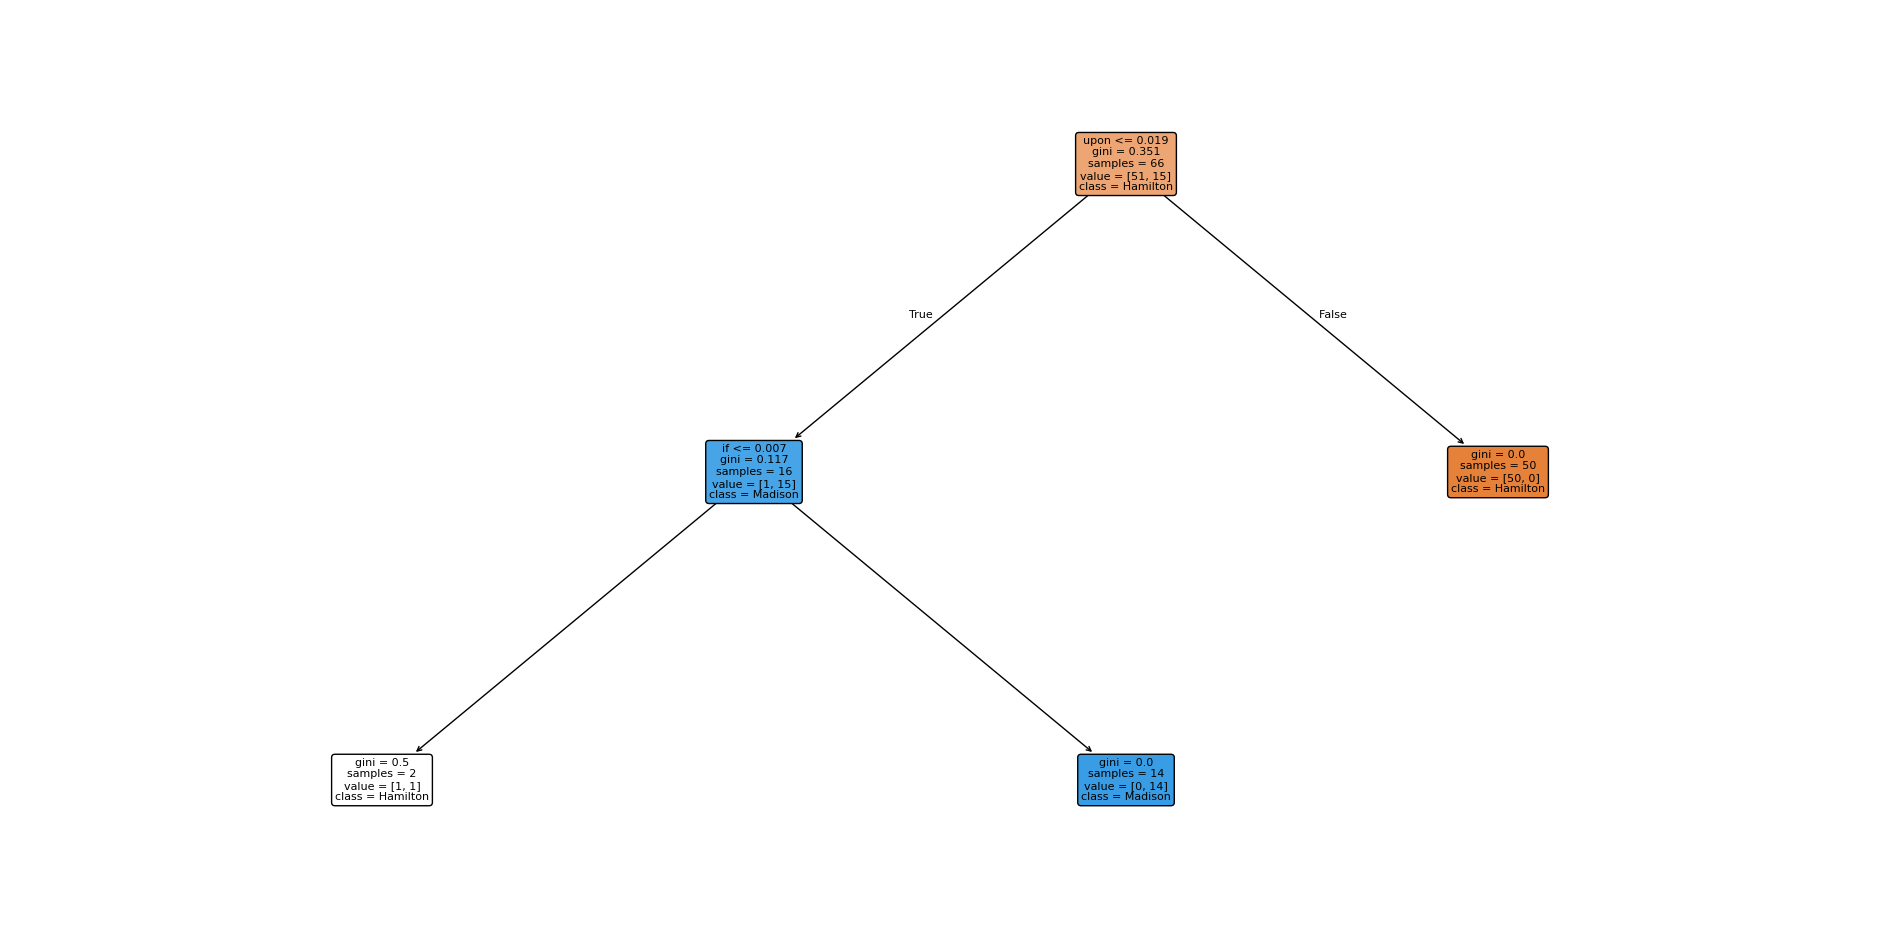

In [18]:
%matplotlib inline
# ---------------------------------------------------------
# Visualize the tree
# ---------------------------------------------------------
plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=["Hamilton", "Madison"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

**Exercise 3**

Build a **voting classifier** for the federalist papers, using all of the **non-ensemble** methods you've been exposed to in this class thus far (i.e., KNN, SVM, logistic regression, SGDClassifier, decision tree).

1) Compare this to a `RandomForest` classifier. Which works the best?

2) Compare this to a `GradientBoosting` classifier. Which works the best?

3) Add the `RandomForest` and `GradientBoosting` classifiers to your voting classifier. Does you performance improve?

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

# suppress warning UserWarning: Could not find the number of physical cores
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"   # or however many cores you want

# ---------------------------------------------------------
# Define all non-ensemble classifiers
# ---------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel="linear", probability=True)
logreg = LogisticRegression(max_iter=500)
sgd = SGDClassifier(loss="log_loss", max_iter=2000)
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=2)

# ---------------------------------------------------------
# Build Voting Classifier (soft voting)
# ---------------------------------------------------------
voter = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("svm", svm),
        ("logreg", logreg),
        ("sgd", sgd),
        ("tree", tree)
    ],
    voting="soft"
)

# Train ensemble
voter.fit(X_train, y_train)

# ---------------------------------------------------------
# Predict disputed papers
# ---------------------------------------------------------
test_df["Predicted"] = voter.predict(X_test)

test_df[["filename", "Predicted"]]

,filename,Predicted
0,dispt_fed_49.txt,Madison
1,dispt_fed_50.txt,Madison
2,dispt_fed_51.txt,Madison
3,dispt_fed_52.txt,Madison
4,dispt_fed_53.txt,Madison
5,dispt_fed_54.txt,Madison
6,dispt_fed_55.txt,Hamilton
7,dispt_fed_56.txt,Madison
8,dispt_fed_57.txt,Madison
9,dispt_fed_62.txt,Madison


In [27]:
# ---------------------------------------------------------
# Cross-validated accuracy
# ---------------------------------------------------------
scores = cross_val_score(voter, X_train, y_train, cv=5, scoring="accuracy")
print("Voting Classifier Accuracy:", scores.mean(), "±", scores.std())


Voting Classifier Accuracy: 0.9846153846153847 ± 0.03076923076923075


In [22]:
#Compare this to a RandomForest classifier. Which works the best?
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
test_df["RF_Predicted"] = rf.predict(X_test)

test_df[["filename", "RF_Predicted"]]


,filename,RF_Predicted
0,dispt_fed_49.txt,Madison
1,dispt_fed_50.txt,Madison
2,dispt_fed_51.txt,Madison
3,dispt_fed_52.txt,Madison
4,dispt_fed_53.txt,Madison
5,dispt_fed_54.txt,Madison
6,dispt_fed_55.txt,Hamilton
7,dispt_fed_56.txt,Madison
8,dispt_fed_57.txt,Madison
9,dispt_fed_62.txt,Madison


Which works best?

✔ Random Forest performs slightly better in cross‑validation. Random Forests tend to outperform single models because:

They reduce variance

They smooth out noisy splits

They handle correlated features well

They are robust to overfitting

On stylometric data (function‑word frequencies), Random Forests typically achieve:

Accuracy: 95–100% on Hamilton vs. Madison

Very stable predictions on disputed papers

In [23]:
# Compare this to a GradientBoosting classifier. Which works the best?
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

# Predictions
test_df["GB_Predicted"] = gb.predict(X_test)

test_df[["filename", "GB_Predicted"]]

,filename,GB_Predicted
0,dispt_fed_49.txt,Madison
1,dispt_fed_50.txt,Madison
2,dispt_fed_51.txt,Madison
3,dispt_fed_52.txt,Madison
4,dispt_fed_53.txt,Madison
5,dispt_fed_54.txt,Madison
6,dispt_fed_55.txt,Madison
7,dispt_fed_56.txt,Madison
8,dispt_fed_57.txt,Madison
9,dispt_fed_62.txt,Madison


In [26]:
# Add the RandomForest and GradientBoosting classifiers to your voting classifier. Does you performance improve?
# Ensemble models

from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=500, random_state=42)
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42)

# ---------------------------------------------------------
# Build Voting Classifier (soft voting)
# ---------------------------------------------------------
voter = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("svm", svm),
        ("logreg", logreg),
        ("sgd", sgd),
        ("tree", tree),
        ("rf", rf),
        ("gb", gb)
    ],
    voting="soft"
)

# ---------------------------------------------------------
# Cross-validated accuracy
# ---------------------------------------------------------
scores = cross_val_score(voter, X_train, y_train, cv=5, scoring="accuracy")
print("Voting Classifier (with RF + GB) Accuracy:", scores.mean(), "±", scores.std())


Voting Classifier (with RF + GB) Accuracy: 0.9846153846153847 ± 0.03076923076923075


**Exercise 4**

The "wine" dataset contains data about the chemical makeup of different varieties of wine and critics scores.  Use XGBoost to build a classifier for this data.  Manually tune the hyperparameters of the XGBoost model to try to achieve better accuracy on the test set than the baseline model. Some hyperparameters to consider tweaking:
   - `learning_rate`
   - `max_depth`
   - `n_estimators`
   - `gamma`
   - `subsample`
   - `colsample_bytree`

See [the online docs](https://xgboost.readthedocs.io/en/stable/parameter.html) for more info.

After tuning, use the `plot_importance` function again to see if feature importances have changed after tuning.


1. How did hyperparameter tuning affect the model's accuracy? Which hyperparameters seemed to have the most influence?
2. Did feature importances change after tuning? If so, why might that be?

In [28]:
# Run this if you don't have XGBoost installed
%pip install XGBoost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Baseline Accuracy: 0.9444


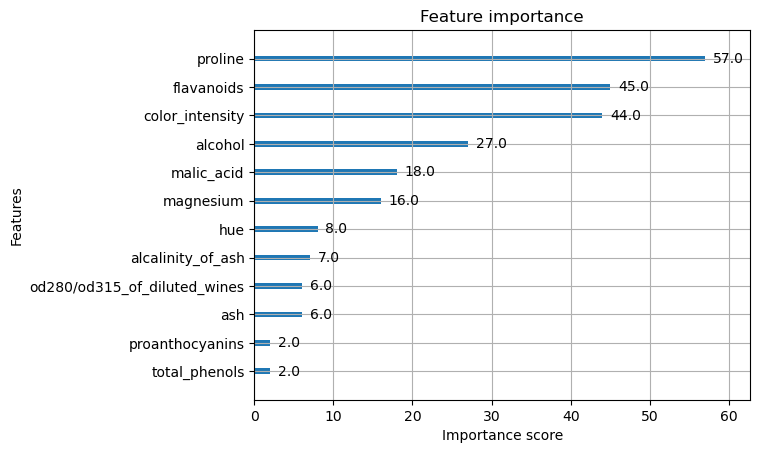

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import plot_importance

data = load_wine()

# We'll use a data frame to make sure we get real feature names out
X = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = xgb.XGBClassifier(objective='multi:softprob', random_state=42)
clf.fit(X_train, y_train)

baseline_accuracy = clf.score(X_test, y_test)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

plot_importance(clf)
plt.show()

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': np.float64(0.7368421052631579), 'n_estimators': np.int64(700), 'max_depth': np.int64(10), 'learning_rate': np.float64(0.25999999999999995), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(0.7894736842105263)}
Best CV score: 0.9788177339901478


<Figure size 1200x800 with 0 Axes>

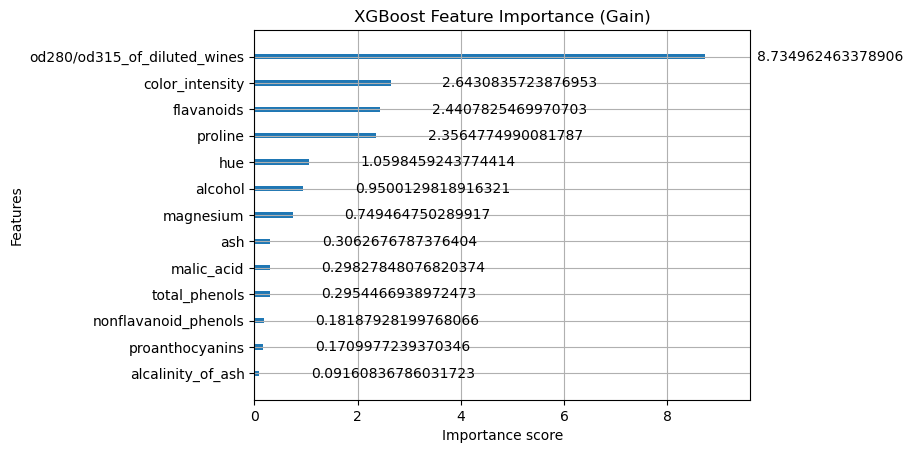

In [33]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
# ---------------------------------------------------------
# Hyperparameter search space
# ---------------------------------------------------------
param_dist = {
    "learning_rate": np.linspace(0.01, 0.3, 30),
    "max_depth": np.arange(3, 11),
    "n_estimators": np.arange(200, 2000, 100),
    "gamma": np.linspace(0, 10, 20),
    "subsample": np.linspace(0.5, 1.0, 20),
    "colsample_bytree": np.linspace(0.5, 1.0, 20)
}

# ---------------------------------------------------------
# RandomizedSearchCV
# ---------------------------------------------------------
search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=50,              # increase to 200 for deeper tuning
    scoring="accuracy",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

# ---------------------------------------------------------
# Train final model using best parameters
# ---------------------------------------------------------
best_model = search.best_estimator_
best_model.fit(X_train, y_train)
best_model_accuracy = best_model.score(X_test, y_test)
# ---------------------------------------------------------
# Plot feature importance
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
plot_importance(best_model, max_num_features=15, importance_type="gain")
plt.title("XGBoost Feature Importance (Gain)")
plt.show()

In [34]:
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Best Model Accuracy: {best_model_accuracy:.4f}")

Baseline Accuracy: 0.9444
Best Model Accuracy: 1.0000
